# Лабораторная работа: Детекция объектов (упрощённый YOLO)

**Дисциплина:** Распознавание образов и индуктивное моделирование (РОИМ)
**Тема:** Детекция объектов, grid-based предсказание, YOLO-loss, NMS.

## Цель работы
Реализовать с нуля упрощённую модель **YOLO-v1** и обучить её детектировать объекты двух классов (круги и квадраты) на синтетических изображениях.

## Что нужно сделать
1. Изучить готовый синтетический датасет и визуализацию bbox.
2. Реализовать кодирование разметки в **YOLO-target тензор**.
3. Реализовать архитектуру `SimpleYOLO` (CNN-бэкбон + detection head).
4. Реализовать `yolo_loss` (локализация + objectness + классификация).
5. Реализовать декодирование предсказаний и **NMS**.
6. Обучить модель и визуализировать предсказанные bbox.
7. Сделать выводы.

---
## Теоретический контекст

В отличие от **классификации** (один класс на всё изображение) и **сегментации** (один класс на пиксель), задача **детекции** требует выдать список объектов — каждый с **bounding box** $(x, y, w, h)$ и меткой класса.

### Идея YOLO (You Only Look Once)

YOLO разбивает изображение на **сетку $S \times S$** и заставляет каждую ячейку предсказывать $B$ боксов и вероятности классов. В упрощённой версии ($B = 1$):

Каждая ячейка $(i, j)$ предсказывает вектор размерности $5 + C$:
$$
(t_x,\; t_y,\; t_w,\; t_h,\; \text{conf},\; p_1, \ldots, p_C),
$$
где:
- $(t_x, t_y) \in [0, 1]$ — координаты центра объекта **относительно ячейки**;
- $(t_w, t_h) \in [0, 1]$ — ширина и высота объекта **относительно всего изображения**;
- $\text{conf}$ — уверенность, что в ячейке есть объект;
- $p_c$ — логит класса.

Вся модель — обычный CNN, выход которого имеет форму $(B,\; 5+C,\; S,\; S)$. Эта «трёхмерная» свёртка и есть «вы смотрите на изображение один раз» — отсюда и название.

### Кодирование разметки

Для каждого объекта $(c_x, c_y, w, h, \text{class})$:
1. определяем «ответственную» ячейку $(i, j)$, в центре которой находится объект:
   $$
   j = \lfloor c_x \cdot S \rfloor, \quad i = \lfloor c_y \cdot S \rfloor.
   $$
2. сохраняем в этой ячейке:
   $$
   t_x = c_x \cdot S - j, \quad t_y = c_y \cdot S - i, \quad t_w = w, \quad t_h = h, \quad \text{conf} = 1.
   $$

Ячейки без объекта имеют $\text{conf} = 0$; их координаты и класс **в лосс не входят**.

### YOLO loss (упрощённая версия)

$$
\mathcal{L} = \lambda_{\text{coord}} \mathcal{L}_{\text{coord}} \,+\, \mathcal{L}_{\text{obj}} \,+\, \lambda_{\text{noobj}} \mathcal{L}_{\text{noobj}} \,+\, \mathcal{L}_{\text{class}}.
$$

Стандартные значения: $\lambda_{\text{coord}} = 5$, $\lambda_{\text{noobj}} = 0.5$.

### Инференс и NMS

После прямого прохода для каждой ячейки получаем bbox и его уверенность. Часто несколько соседних ячеек «голосуют» за один и тот же объект. **Non-Maximum Suppression** жадно оставляет наиболее уверенный bbox и удаляет все с $\text{IoU} > \tau$ из числа оставшихся.


---

> Версия заполнена как готовая сдаваемая работа: реализованы основные TODO, добавлены sanity-checks, основной эксперимент, ответы для отчёта и дополнительные задания из §11.

In [1]:
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

plt.rcParams["figure.figsize"] = (8, 8)
plt.rcParams["font.size"] = 11

IMG_SIZE = 64
GRID = 4              # размер сетки SxS
NUM_CLASSES = 2       # 0 = круг, 1 = квадрат
CLASS_NAMES = ["circle", "square"]

Device: cuda


# 1. Синтетический датасет

- Изображение $64 \times 64$, один канал, шумный фон.
- На каждое изображение помещаются $1$–$3$ объекта:
  - **класс 0** — круг радиуса 4–10;
  - **класс 1** — квадрат стороны 8–18.
- Разметка: список боксов `(cx, cy, w, h, class)`, все координаты **относительные** (в $[0, 1]$).

Датасет уже реализован.

In [2]:
def _draw_circle(img, cx, cy, r):
    H, W = img.shape
    yy, xx = np.mgrid[0:H, 0:W]
    mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= r ** 2
    img[mask] = 0.85


def _draw_square(img, cx, cy, side):
    H, W = img.shape
    half = side // 2
    x0, y0 = max(0, cx - half), max(0, cy - half)
    x1, y1 = min(W, cx + half), min(H, cy + half)
    img[y0:y1, x0:x1] = 0.85


def _make_sample(rng):
    img = rng.normal(loc=0.3, scale=0.12, size=(IMG_SIZE, IMG_SIZE)).astype(np.float32)
    boxes = []
    n_objects = rng.integers(1, 4)
    for _ in range(int(n_objects)):
        cls = int(rng.integers(0, NUM_CLASSES))
        if cls == 0:
            r = rng.integers(4, 11)
            cx_px = rng.integers(r + 1, IMG_SIZE - r - 1)
            cy_px = rng.integers(r + 1, IMG_SIZE - r - 1)
            _draw_circle(img, cx_px, cy_px, r)
            w_px, h_px = 2 * r, 2 * r
        else:
            side = rng.integers(8, 19)
            half = side // 2
            cx_px = rng.integers(half + 1, IMG_SIZE - half - 1)
            cy_px = rng.integers(half + 1, IMG_SIZE - half - 1)
            _draw_square(img, cx_px, cy_px, side)
            w_px = h_px = side

        # относительные координаты (нормировка на IMG_SIZE)
        boxes.append([cx_px / IMG_SIZE, cy_px / IMG_SIZE,
                      w_px / IMG_SIZE, h_px / IMG_SIZE, cls])

    img = np.clip(img, 0.0, 1.0)
    return img, np.array(boxes, dtype=np.float32)


class SyntheticDetDataset(Dataset):
    def __init__(self, n_samples=256, seed=0):
        self.rng = np.random.default_rng(seed)
        self._cache = [_make_sample(self.rng) for _ in range(n_samples)]

    def __len__(self):
        return len(self._cache)

    def __getitem__(self, idx):
        img, boxes = self._cache[idx]
        return torch.from_numpy(img).unsqueeze(0), torch.from_numpy(boxes)


def det_collate(batch):
    """Кастомный collate: боксов в каждом примере разное количество."""
    imgs = torch.stack([b[0] for b in batch])
    boxes_list = [b[1] for b in batch]
    return imgs, boxes_list

# 2. Визуализация

`draw_boxes(img, boxes, ...)` рисует список bbox-ов поверх изображения. Уже реализована.

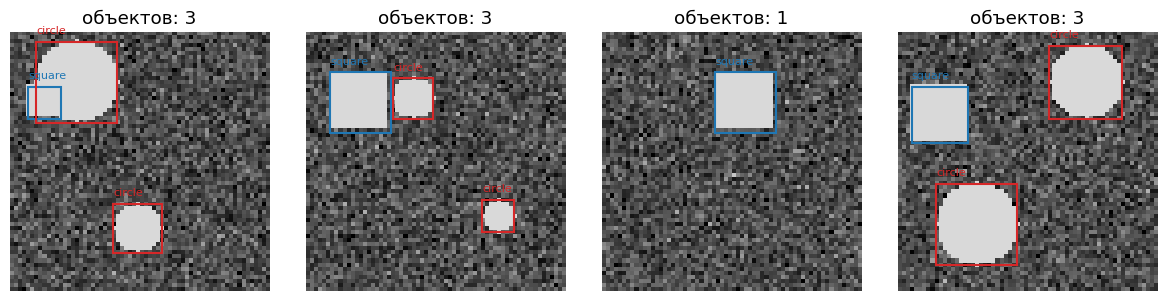

In [3]:
COLORS = {0: "tab:red", 1: "tab:blue"}


def draw_boxes(ax, img, boxes, title=""):
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")
    for box in boxes:
        cx, cy, w, h, cls = box[:5]
        score = box[5] if len(box) > 5 else None
        x = (cx - w / 2) * IMG_SIZE
        y = (cy - h / 2) * IMG_SIZE
        rect = mpatches.Rectangle((x, y), w * IMG_SIZE, h * IMG_SIZE,
                                  linewidth=1.5, edgecolor=COLORS[int(cls)],
                                  facecolor="none")
        ax.add_patch(rect)
        label = CLASS_NAMES[int(cls)]
        if score is not None:
            label = f"{label} {score:.2f}"
        ax.text(x, y - 2, label, color=COLORS[int(cls)], fontsize=8)


def preview_dataset(ds, n=4):
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    for i in range(n):
        img, boxes = ds[i]
        draw_boxes(axes[i], img[0].numpy(), boxes.numpy(),
                   title=f"объектов: {len(boxes)}")
    plt.tight_layout(); plt.show()


train_ds = SyntheticDetDataset(n_samples=384, seed=0)
val_ds   = SyntheticDetDataset(n_samples=64,  seed=999)
preview_dataset(train_ds, n=4)

# 3. Кодирование разметки в YOLO-target

Из списка боксов нужно построить тензор формы $(5 + C,\; S,\; S)$ — таргет для одного изображения.

В канал $0$ записываем $\text{conf}$ (1 в ячейках с объектом, 0 — иначе). В каналы $1$–$4$ — $(t_x, t_y, t_w, t_h)$. В каналы $5\ldots 5+C-1$ — one-hot класса.

## Задание
Реализуйте `encode_target(boxes, S, C)`.

In [4]:
def encode_target(boxes, S=GRID, C=NUM_CLASSES):
    """
    boxes : tensor (N, 5) — каждая строка (cx, cy, w, h, class), координаты в [0, 1].
    Возвращает тензор (5 + C, S, S).

    Раскладка по каналам:
      0       : conf (1 если в ячейке есть объект, 0 иначе)
      1..4    : t_x, t_y, t_w, t_h
      5..5+C-1: one-hot класса
    """
    target = torch.zeros(5 + C, S, S, dtype=torch.float32)

    # В упрощённом YOLO-v1 одна ячейка отвечает максимум за один объект.
    # Если два центра попали в одну ячейку, оставляем первый объект — это соответствует
    # условию задания и делает target однозначным.
    for box in boxes:
        cx, cy, w, h, cls = box.tolist()
        cx = float(np.clip(cx, 0.0, 1.0))
        cy = float(np.clip(cy, 0.0, 1.0))
        w = float(np.clip(w, 1e-6, 1.0))
        h = float(np.clip(h, 1e-6, 1.0))
        cls = int(cls)

        j = min(int(cx * S), S - 1)  # x-index ячейки
        i = min(int(cy * S), S - 1)  # y-index ячейки

        if target[0, i, j] == 1:
            continue

        tx = cx * S - j
        ty = cy * S - i

        target[0, i, j] = 1.0
        target[1:5, i, j] = torch.tensor([tx, ty, w, h], dtype=torch.float32)
        target[5 + cls, i, j] = 1.0

    return target


In [5]:
def encode_batch(boxes_list, S=GRID, C=NUM_CLASSES):
    return torch.stack([encode_target(b, S, C) for b in boxes_list])

# 4. Архитектура `SimpleYOLO`

Маленький CNN, который из $1 \times 64 \times 64$ делает $(5 + C) \times 4 \times 4$.

```
1×64×64
  → Conv(1→16)  + BN + ReLU + MaxPool(2)   → 16×32×32
  → Conv(16→32) + BN + ReLU + MaxPool(2)   → 32×16×16
  → Conv(32→64) + BN + ReLU + MaxPool(2)   → 64×8×8
  → Conv(64→128) + BN + ReLU + MaxPool(2)  → 128×4×4
  → Conv1×1(128 → 5 + C)                   → (5+C)×4×4   ← raw output
```

Все Conv — `3×3, padding=1`. Финальный Conv `1×1` выдаёт **логиты** — никакой сигмоиды/софтмакса в `forward`!

## Задание
Реализуйте класс.

In [6]:
def conv_bn_relu(in_c, out_c):
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(out_c),
        nn.ReLU(inplace=True),
    )


class SimpleYOLO(nn.Module):
    def __init__(self, S=GRID, C=NUM_CLASSES):
        super().__init__()
        self.S = S
        self.C = C
        self.backbone = nn.Sequential(
            conv_bn_relu(1, 16),   nn.MaxPool2d(2),  # 64 -> 32
            conv_bn_relu(16, 32),  nn.MaxPool2d(2),  # 32 -> 16
            conv_bn_relu(32, 64),  nn.MaxPool2d(2),  # 16 -> 8
            conv_bn_relu(64, 128), nn.MaxPool2d(2),  # 8 -> 4
        )
        self.head = nn.Conv2d(128, 5 + C, kernel_size=1)

    def forward(self, x):
        # Выходной тензор: (B, 5+C, S, S) — логиты, без sigmoid/softmax.
        x = self.backbone(x)
        return self.head(x)


# 5. Loss-функция

Для каждого батча модель выдаёт `pred`: $(B,\; 5+C,\; S,\; S)$.
Таргет `target`: тот же размер, в нулевом канале — маска ячеек с объектом.

Расчёт лосса:
1. `obj_mask  = target[:, 0:1] == 1`     — где есть объект,
2. `noobj_mask = target[:, 0:1] == 0`    — пустые ячейки.
3. **Объектность.** Применяем `sigmoid` к `pred[:, 0]` и считаем MSE:
   - в `obj_mask`-ячейках — против $1$ (вклад в $\mathcal{L}_{\text{obj}}$);
   - в `noobj_mask`-ячейках — против $0$ (вклад в $\mathcal{L}_{\text{noobj}}$).
4. **Координаты.** Считаем MSE только в obj-ячейках:
   - `sigmoid(pred[1:5])` против `target[1:5]`.
5. **Классификация.** В obj-ячейках берём `pred[5:]` (логиты) и `target[5:]` (one-hot), считаем cross-entropy:
   - `class_idx = argmax(target[5:], dim=1)`
   - `F.cross_entropy(pred[5:], class_idx, reduction="sum")` по obj-ячейкам.
6. Финальный лосс: $5 \cdot \mathcal{L}_{\text{coord}} + \mathcal{L}_{\text{obj}} + 0.5 \cdot \mathcal{L}_{\text{noobj}} + \mathcal{L}_{\text{class}}$, делённый на размер батча.

## Задание
Реализуйте `yolo_loss(pred, target)`.

In [7]:
def yolo_loss(pred, target, lambda_coord=5.0, lambda_noobj=0.5):
    """
    pred, target: (B, 5 + C, S, S)
    Каналы: conf, tx, ty, tw, th, class_logits...
    """
    B = pred.shape[0]
    obj_mask   = (target[:, 0:1] == 1)       # (B, 1, S, S), bool
    noobj_mask = (target[:, 0:1] == 0)

    # 1. Objectness: sigmoid переводит логит уверенности в [0, 1].
    conf_pred = torch.sigmoid(pred[:, 0:1])
    loss_obj = ((conf_pred - 1.0) ** 2 * obj_mask.float()).sum()
    loss_noobj = (conf_pred ** 2 * noobj_mask.float()).sum()

    # 2. Координаты считаются только в ячейках с объектом.
    coord_pred = torch.sigmoid(pred[:, 1:5])
    coord_target = target[:, 1:5]
    loss_coord = ((coord_pred - coord_target) ** 2 * obj_mask.float()).sum()

    # 3. Классификация только в obj-ячейках.
    class_logits = pred[:, 5:]
    class_idx = target[:, 5:].argmax(dim=1)  # (B, S, S)
    logits_flat = class_logits.permute(0, 2, 3, 1).reshape(-1, class_logits.shape[1])
    idx_flat = class_idx.reshape(-1)
    mask_flat = obj_mask[:, 0].reshape(-1).bool()

    if mask_flat.any():
        loss_class = F.cross_entropy(logits_flat[mask_flat], idx_flat[mask_flat], reduction="sum")
    else:
        loss_class = torch.tensor(0.0, device=pred.device)

    total = lambda_coord * loss_coord + loss_obj + lambda_noobj * loss_noobj + loss_class
    return total / B


# 6. Декодирование предсказаний

Чтобы из тензора $(5 + C,\; S,\; S)$ получить **список боксов** для одного изображения:
1. `conf = sigmoid(pred[0])`        — карта уверенностей $(S, S)$.
2. Отбираем ячейки с `conf > conf_thr`.
3. Для каждой такой ячейки $(i, j)$:
   - $c_x = (j + \sigma(t_x)) / S$, $c_y = (i + \sigma(t_y)) / S$,
   - $w = \sigma(t_w)$, $h = \sigma(t_h)$,
   - класс = `argmax(pred[5:, i, j])`.
4. Возвращаем тензор $(N, 6)$: `(cx, cy, w, h, class, score)`.

## Задание
Реализуйте `decode_predictions(pred, conf_thr)`.

In [8]:
def decode_predictions(pred, conf_thr=0.5, S=GRID, C=NUM_CLASSES):
    """
    pred : (5 + C, S, S) — выход модели для ОДНОГО изображения.
    Возвращает тензор (N, 6): cx, cy, w, h, class, score.
    """
    boxes = []
    conf = torch.sigmoid(pred[0])           # (S, S)
    coords = torch.sigmoid(pred[1:5])       # (4, S, S)
    class_logits = pred[5:]                 # (C, S, S)

    for i in range(S):
        for j in range(S):
            score = conf[i, j]
            if score <= conf_thr:
                continue

            tx, ty, w, h = coords[:, i, j]
            cx = (j + tx) / S
            cy = (i + ty) / S
            cls = torch.argmax(class_logits[:, i, j]).float()

            boxes.append(torch.stack([
                cx.clamp(0, 1),
                cy.clamp(0, 1),
                w.clamp(1e-6, 1),
                h.clamp(1e-6, 1),
                cls,
                score.clamp(0, 1),
            ]))

    if not boxes:
        return torch.zeros(0, 6, device=pred.device)
    return torch.stack(boxes)


# 7. Non-Maximum Suppression

Чтобы убрать дубликаты:
1. Отсортируйте боксы по `score` (убывание).
2. Возьмите первый — он точно остаётся в результате.
3. Удалите все из оставшихся, у которых `IoU` с ним $> \tau$ **и тот же класс**.
4. Повторяйте с оставшимися.

`bbox_iou_xywh(a, b)` — IoU двух bbox в формате `(cx, cy, w, h)`.

## Задание
Реализуйте `bbox_iou_xywh` (готова) и `nms(boxes, iou_thr)`.

In [9]:
def bbox_iou_xywh(a, b):
    """a, b — тензоры/массивы (cx, cy, w, h). Возвращает скаляр IoU как float."""
    a = torch.as_tensor(a[:4], dtype=torch.float32)
    b = torch.as_tensor(b[:4], dtype=torch.float32)

    ax1, ay1 = a[0] - a[2] / 2, a[1] - a[3] / 2
    ax2, ay2 = a[0] + a[2] / 2, a[1] + a[3] / 2
    bx1, by1 = b[0] - b[2] / 2, b[1] - b[3] / 2
    bx2, by2 = b[0] + b[2] / 2, b[1] + b[3] / 2

    inter_x1 = torch.maximum(ax1, bx1)
    inter_y1 = torch.maximum(ay1, by1)
    inter_x2 = torch.minimum(ax2, bx2)
    inter_y2 = torch.minimum(ay2, by2)

    inter = torch.clamp(inter_x2 - inter_x1, min=0.0) * torch.clamp(inter_y2 - inter_y1, min=0.0)
    area_a = torch.clamp(ax2 - ax1, min=0.0) * torch.clamp(ay2 - ay1, min=0.0)
    area_b = torch.clamp(bx2 - bx1, min=0.0) * torch.clamp(by2 - by1, min=0.0)
    union = area_a + area_b - inter

    if union.item() <= 0:
        return 0.0
    return float((inter / union).item())

In [10]:
def nms(boxes, iou_thr=0.4):
    """
    boxes : (N, 6) — cx, cy, w, h, class, score
    Возвращает отфильтрованный тензор той же формы.
    """
    if boxes.numel() == 0:
        return boxes

    order = torch.argsort(boxes[:, 5], descending=True)
    boxes = boxes[order]
    keep = []

    while boxes.numel() > 0:
        current = boxes[0]
        keep.append(current)
        if len(boxes) == 1:
            break

        rest = boxes[1:]
        filtered = []
        for candidate in rest:
            same_class = int(candidate[4].item()) == int(current[4].item())
            too_close = bbox_iou_xywh(current[:4], candidate[:4]) > iou_thr
            if not (same_class and too_close):
                filtered.append(candidate)

        if not filtered:
            break
        boxes = torch.stack(filtered)

    if keep:
        return torch.stack(keep).to(device=boxes.device)
    return torch.zeros(0, 6, device=boxes.device, dtype=boxes.dtype)

## Быстрая проверка основных компонентов

Эта ячейка не обучает модель, а только проверяет, что target-кодирование, forward-pass, loss, decoding и NMS совместимы по формам.

In [11]:
# Sanity-check: можно запускать перед долгим обучением.
_img, _boxes = train_ds[0]
_t = encode_target(_boxes)
assert _t.shape == (5 + NUM_CLASSES, GRID, GRID)

_tmp_model = SimpleYOLO().to(DEVICE)
_tmp_batch = _img.unsqueeze(0).to(DEVICE)
_tmp_pred = _tmp_model(_tmp_batch)
assert _tmp_pred.shape == (1, 5 + NUM_CLASSES, GRID, GRID)

_tmp_target = encode_batch([_boxes]).to(DEVICE)
_tmp_loss = yolo_loss(_tmp_pred, _tmp_target)
assert torch.isfinite(_tmp_loss), "loss должен быть конечным"

_tmp_decoded = decode_predictions(_tmp_pred[0].detach().cpu(), conf_thr=0.1)
_tmp_nms = nms(_tmp_decoded, iou_thr=0.4)
print("OK:", _t.shape, _tmp_pred.shape, "loss=", float(_tmp_loss.detach().cpu()))

OK: torch.Size([7, 4, 4]) torch.Size([1, 7, 4, 4]) loss= 15.18334674835205


# 8. Обучающий цикл

Стандартный PyTorch-цикл. Уже реализован.

In [12]:
def train_yolo(model, train_loader, val_loader, epochs=30, lr=1e-3,
               conf_thr=0.5, iou_thr=0.5, device=DEVICE):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_precision": [], "val_recall": []}

    for epoch in range(epochs):
        model.train()
        total = 0.0
        for imgs, boxes_list in train_loader:
            imgs = imgs.to(device)
            target = encode_batch(boxes_list).to(device)
            pred = model(imgs)
            loss = yolo_loss(pred, target)
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += loss.item() * imgs.size(0)
        epoch_loss = total / len(train_loader.dataset)

        # простая оценка качества: precision/recall при IoU > 0.5 и совпадении класса
        model.eval()
        tp = fp = fn = 0
        with torch.no_grad():
            for imgs, boxes_list in val_loader:
                imgs = imgs.to(device)
                preds = model(imgs)
                for b in range(imgs.size(0)):
                    decoded = decode_predictions(preds[b], conf_thr=conf_thr)
                    decoded = nms(decoded, iou_thr=0.4)
                    gt = boxes_list[b]
                    tp_b, fp_b, fn_b = match_boxes(decoded, gt, iou_thr=iou_thr)
                    tp += tp_b; fp += fp_b; fn += fn_b
        precision = tp / max(1, tp + fp)
        recall    = tp / max(1, tp + fn)

        history["train_loss"].append(epoch_loss)
        history["val_precision"].append(precision)
        history["val_recall"].append(recall)
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"[epoch {epoch+1:2d}] loss={epoch_loss:.3f}  "
                  f"P={precision:.2f}  R={recall:.2f}")
    return history


def match_boxes(pred_boxes, gt_boxes, iou_thr=0.5):
    """Жадное сопоставление: для каждого GT находим лучший pred с тем же классом."""
    pred_used = [False] * len(pred_boxes)
    tp = 0
    for g in gt_boxes:
        best_iou, best_p = 0.0, -1
        for p_idx, p in enumerate(pred_boxes):
            if pred_used[p_idx]:
                continue
            if int(p[4].item()) != int(g[4].item()):
                continue
            iou = bbox_iou_xywh(p[:4], g[:4])
            if iou > best_iou:
                best_iou, best_p = iou, p_idx
        if best_iou >= iou_thr:
            tp += 1
            pred_used[best_p] = True
    fp = sum(1 for u in pred_used if not u) if pred_boxes.numel() else 0
    fn = len(gt_boxes) - tp
    return tp, fp, fn

# 9. Эксперимент: обучение и визуализация

Обучите модель (`epochs=30`, `batch_size=16`, `lr=1e-3`), постройте кривые `train_loss`, `val_precision`, `val_recall` и визуализируйте предсказания на 4 примерах из валидации.

## Задание
Раскомментируйте код после реализации всех функций.

[epoch  1] loss=2.609  P=0.00  R=0.00
[epoch  5] loss=0.247  P=0.80  R=0.76
[epoch 10] loss=0.061  P=0.82  R=0.76
[epoch 15] loss=0.042  P=0.77  R=0.71
[epoch 20] loss=0.032  P=0.82  R=0.74
[epoch 25] loss=0.025  P=0.84  R=0.74
[epoch 30] loss=0.028  P=0.85  R=0.74


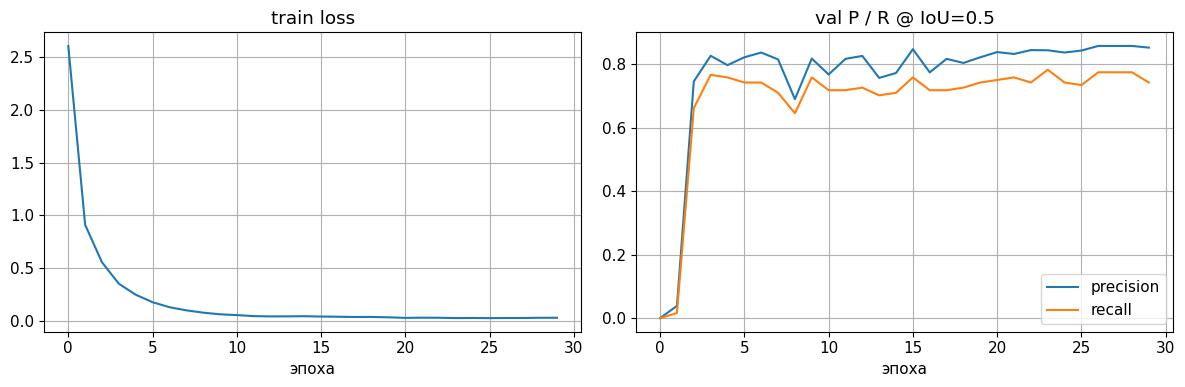

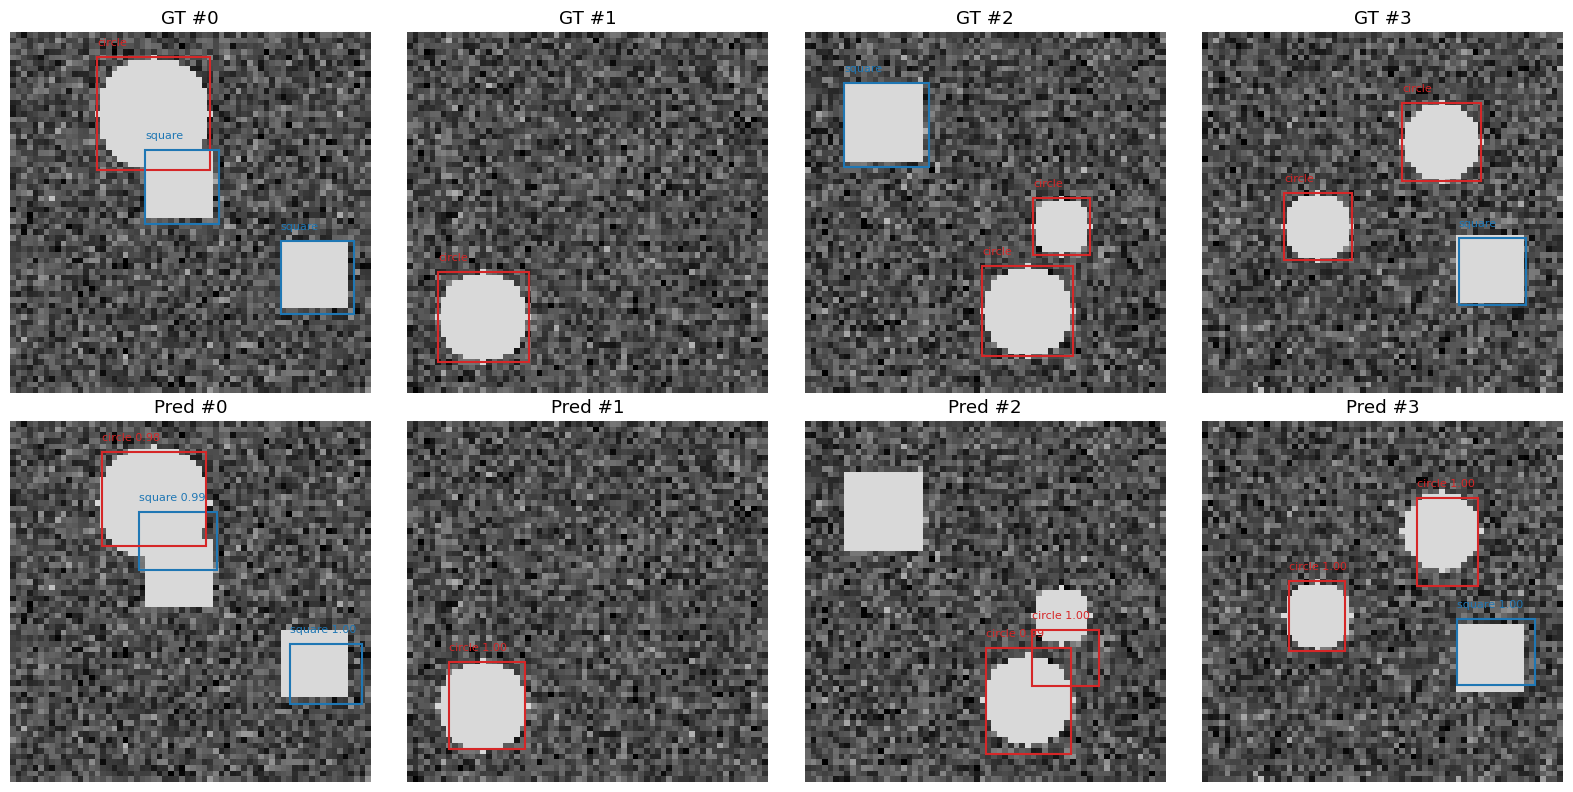

In [13]:
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, collate_fn=det_collate)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False, collate_fn=det_collate)

# Для быстрой проверки на CPU можно временно поставить EPOCHS = 3-5.
# Для сдачи оставляем рекомендованные 30 эпох.
EPOCHS = 30

model = SimpleYOLO().to(DEVICE)
history = train_yolo(model, train_loader, val_loader, epochs=EPOCHS, lr=1e-3)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"])
axes[0].set_title("train loss")
axes[0].set_xlabel("эпоха")
axes[0].grid(True)

axes[1].plot(history["val_precision"], label="precision")
axes[1].plot(history["val_recall"],    label="recall")
axes[1].set_title("val P / R @ IoU=0.5")
axes[1].set_xlabel("эпоха")
axes[1].legend()
axes[1].grid(True)
plt.tight_layout(); plt.show()

# Визуализация на 4 примерах
model.eval()
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
with torch.no_grad():
    for i in range(4):
        img, gt = val_ds[i]
        pred = model(img.unsqueeze(0).to(DEVICE))[0].cpu()
        decoded = decode_predictions(pred, conf_thr=0.5)
        decoded = nms(decoded, iou_thr=0.4)
        draw_boxes(axes[0, i], img[0].numpy(), gt.numpy(), title=f"GT #{i}")
        draw_boxes(axes[1, i], img[0].numpy(), decoded.numpy(), title=f"Pred #{i}")
plt.tight_layout(); plt.show()


## 9.1. Наглядная диагностика предсказаний YOLO

Одних `precision/recall` мало: хочется видеть, **где именно модель ошибается**. Ниже добавлены визуальные диагностические ячейки:

- overlay `GT` и `Pred` на одном изображении;
- разметка ошибок: `TP`, `FP`, `FN`;
- objectness-map по ячейкам сетки;
- сравнение сырых предсказаний до NMS и финальных боксов после NMS;
- автоматический вывод худших/лучших примеров на валидации.

Запускать этот блок лучше **после обучения `model`**.

In [14]:

# === Визуальная диагностика YOLO: GT / Pred / TP / FP / FN ===

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


def _to_numpy_boxes(boxes):
    """Переводит tensor/list с bbox в numpy-массив формы (N, 5) или (N, 6)."""
    if boxes is None:
        return np.zeros((0, 6), dtype=np.float32)
    if isinstance(boxes, torch.Tensor):
        boxes = boxes.detach().cpu().numpy()
    boxes = np.asarray(boxes, dtype=np.float32)
    if boxes.size == 0:
        return np.zeros((0, 6), dtype=np.float32)
    if boxes.ndim == 1:
        boxes = boxes[None, :]
    return boxes


def _box_xywh_to_pixels(box, img_size=IMG_SIZE):
    """box: cx, cy, w, h в [0, 1] -> x, y, w, h в пикселях."""
    cx, cy, w, h = [float(v) for v in box[:4]]
    x = (cx - w / 2) * img_size
    y = (cy - h / 2) * img_size
    return x, y, w * img_size, h * img_size


def _draw_one_box(ax, box, color, label, linestyle="-", linewidth=2.0, alpha=1.0):
    x, y, w, h = _box_xywh_to_pixels(box)
    rect = mpatches.Rectangle(
        (x, y), w, h,
        linewidth=linewidth,
        edgecolor=color,
        facecolor="none",
        linestyle=linestyle,
        alpha=alpha,
    )
    ax.add_patch(rect)
    ax.text(
        x,
        max(0, y - 2),
        label,
        color="white",
        fontsize=8,
        bbox=dict(facecolor=color, alpha=0.75, pad=1.5, edgecolor="none"),
    )


def detailed_match_boxes(pred_boxes, gt_boxes, iou_thr=0.5):
    """
    Детальное сопоставление pred и GT.

    pred_boxes: (N, 6): cx, cy, w, h, cls, score
    gt_boxes:   (M, 5): cx, cy, w, h, cls

    Возвращает словарь со статусами:
    - pred_status: TP / FP для каждого предсказания;
    - gt_status: TP / FN для каждого GT;
    - pred_best_iou: лучший IoU для каждого pred с GT того же класса;
    - gt_best_iou: лучший IoU для каждого GT с pred того же класса.
    """
    pred = _to_numpy_boxes(pred_boxes)
    gt = _to_numpy_boxes(gt_boxes)

    if pred.shape[1] < 6:
        # Если вдруг передали GT-like боксы без score.
        score_col = np.ones((len(pred), 1), dtype=np.float32)
        pred = np.concatenate([pred[:, :5], score_col], axis=1)

    pred_status = ["FP"] * len(pred)
    pred_best_iou = [0.0] * len(pred)
    pred_matched_gt = [-1] * len(pred)

    gt_status = ["FN"] * len(gt)
    gt_best_iou = [0.0] * len(gt)
    gt_matched_pred = [-1] * len(gt)

    # Для каждого GT считаем лучший IoU среди предсказаний того же класса — даже если ниже порога.
    for gi, g in enumerate(gt):
        best_iou = 0.0
        for pi, p in enumerate(pred):
            if int(p[4]) != int(g[4]):
                continue
            iou = bbox_iou_xywh(torch.tensor(p[:4]), torch.tensor(g[:4]))
            best_iou = max(best_iou, iou)
        gt_best_iou[gi] = best_iou

    # Жадное сопоставление pred -> GT по score.
    used_gt = set()
    order = np.argsort(-pred[:, 5]) if len(pred) else []
    for pi in order:
        p = pred[pi]
        best_iou, best_gi = 0.0, -1
        for gi, g in enumerate(gt):
            if gi in used_gt:
                continue
            if int(p[4]) != int(g[4]):
                continue
            iou = bbox_iou_xywh(torch.tensor(p[:4]), torch.tensor(g[:4]))
            if iou > best_iou:
                best_iou, best_gi = iou, gi

        pred_best_iou[pi] = best_iou
        if best_iou >= iou_thr and best_gi >= 0:
            pred_status[pi] = "TP"
            pred_matched_gt[pi] = best_gi
            gt_status[best_gi] = "TP"
            gt_matched_pred[best_gi] = pi
            used_gt.add(best_gi)
        else:
            pred_status[pi] = "FP"

    tp = sum(s == "TP" for s in pred_status)
    fp = sum(s == "FP" for s in pred_status)
    fn = sum(s == "FN" for s in gt_status)

    precision = tp / max(1, tp + fp)
    recall = tp / max(1, tp + fn)
    mean_best_iou = float(np.mean(gt_best_iou)) if len(gt_best_iou) else 0.0

    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "mean_best_iou": mean_best_iou,
        "pred_status": pred_status,
        "gt_status": gt_status,
        "pred_best_iou": pred_best_iou,
        "gt_best_iou": gt_best_iou,
        "pred_matched_gt": pred_matched_gt,
        "gt_matched_pred": gt_matched_pred,
    }


def draw_error_overlay(ax, img, gt_boxes, pred_boxes, iou_thr=0.5, title=""):
    """Рисует GT и Pred вместе: TP зелёным, FP красным, FN оранжевым."""
    gt = _to_numpy_boxes(gt_boxes)
    pred = _to_numpy_boxes(pred_boxes)
    stats = detailed_match_boxes(pred, gt, iou_thr=iou_thr)

    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")

    # GT: matched — зелёный, missed — оранжевый.
    for gi, g in enumerate(gt):
        cls_name = CLASS_NAMES[int(g[4])]
        if stats["gt_status"][gi] == "TP":
            label = f"GT {cls_name}"
            _draw_one_box(ax, g, color="limegreen", label=label, linestyle="-", linewidth=2.0, alpha=0.95)
        else:
            label = f"FN {cls_name}"
            _draw_one_box(ax, g, color="orange", label=label, linestyle="-", linewidth=2.5, alpha=0.95)

    # Pred: TP — зелёный пунктир, FP — красный пунктир.
    for pi, p in enumerate(pred):
        cls_name = CLASS_NAMES[int(p[4])]
        score = float(p[5]) if len(p) > 5 else 1.0
        if stats["pred_status"][pi] == "TP":
            label = f"TP {cls_name} {score:.2f}"
            _draw_one_box(ax, p, color="deepskyblue", label=label, linestyle="--", linewidth=1.8, alpha=0.95)
        else:
            label = f"FP {cls_name} {score:.2f}"
            _draw_one_box(ax, p, color="crimson", label=label, linestyle="--", linewidth=1.8, alpha=0.95)

    return stats


def draw_objectness_map(ax, objectness, title="Objectness map"):
    """Показывает уверенность модели по каждой ячейке SxS."""
    objectness = np.asarray(objectness, dtype=np.float32)
    im = ax.imshow(objectness, vmin=0, vmax=1, cmap="viridis")
    ax.set_title(title)
    ax.set_xticks(range(objectness.shape[1]))
    ax.set_yticks(range(objectness.shape[0]))

    for i in range(objectness.shape[0]):
        for j in range(objectness.shape[1]):
            ax.text(j, i, f"{objectness[i, j]:.2f}", ha="center", va="center", color="white", fontsize=8)

    ax.set_xlabel("grid x")
    ax.set_ylabel("grid y")
    return im


@torch.no_grad()
def collect_yolo_diagnostics(
    model,
    loader,
    decode_fn=decode_predictions,
    conf_thr=0.5,
    raw_conf_thr=0.05,
    nms_iou_thr=0.4,
    match_iou_thr=0.5,
    max_batches=None,
    device=DEVICE,
):
    """
    Собирает примеры и агрегированные метрики на val_loader.
    raw_conf_thr нужен для визуализации сырых кандидатов до NMS.
    """
    model.eval()
    model.to(device)

    examples = []
    total_tp = total_fp = total_fn = 0
    total_gt = total_pred = 0
    best_ious = []

    for batch_idx, (imgs, boxes_list) in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        imgs_device = imgs.to(device)
        outputs = model(imgs_device).detach().cpu()

        for b in range(imgs.shape[0]):
            img_np = imgs[b, 0].detach().cpu().numpy()
            gt = boxes_list[b].detach().cpu()
            out = outputs[b]

            raw_pred = decode_fn(out, conf_thr=raw_conf_thr).detach().cpu()
            final_pred = decode_fn(out, conf_thr=conf_thr).detach().cpu()
            final_pred = nms(final_pred, iou_thr=nms_iou_thr).detach().cpu()

            stats = detailed_match_boxes(final_pred, gt, iou_thr=match_iou_thr)
            objectness = torch.sigmoid(out[0]).numpy()

            error_score = 2.0 * stats["fn"] + stats["fp"] + max(0.0, 1.0 - stats["mean_best_iou"])

            examples.append({
                "image": img_np,
                "gt": gt,
                "raw_output": out,
                "objectness": objectness,
                "raw_pred": raw_pred,
                "pred": final_pred,
                "stats": stats,
                "error_score": error_score,
            })

            total_tp += stats["tp"]
            total_fp += stats["fp"]
            total_fn += stats["fn"]
            total_gt += len(gt)
            total_pred += len(final_pred)
            best_ious.extend(stats["gt_best_iou"])

    precision = total_tp / max(1, total_tp + total_fp)
    recall = total_tp / max(1, total_tp + total_fn)

    summary = {
        "TP": total_tp,
        "FP": total_fp,
        "FN": total_fn,
        "Precision": precision,
        "Recall": recall,
        "Mean best IoU per GT": float(np.mean(best_ious)) if best_ious else 0.0,
        "Avg GT per image": total_gt / max(1, len(examples)),
        "Avg predictions per image": total_pred / max(1, len(examples)),
        "Images": len(examples),
    }
    return examples, summary


def print_yolo_diagnostic_summary(summary):
    print("YOLO diagnostic summary")
    print("-" * 32)
    for key, value in summary.items():
        if isinstance(value, float):
            print(f"{key:26s}: {value:.3f}")
        else:
            print(f"{key:26s}: {value}")

    print("\nИнтерпретация:")
    print("TP — найденный объект правильного класса с IoU >= 0.5")
    print("FP — лишний или неверный bbox")
    print("FN — пропущенный объект")
    print("Mean best IoU per GT показывает, насколько близко предсказания подходят к GT даже до жёсткого порога.")


YOLO diagnostic summary
--------------------------------
TP                        : 92
FP                        : 16
FN                        : 32
Precision                 : 0.852
Recall                    : 0.742
Mean best IoU per GT      : 0.580
Avg GT per image          : 1.938
Avg predictions per image : 1.688
Images                    : 64

Интерпретация:
TP — найденный объект правильного класса с IoU >= 0.5
FP — лишний или неверный bbox
FN — пропущенный объект
Mean best IoU per GT показывает, насколько близко предсказания подходят к GT даже до жёсткого порога.


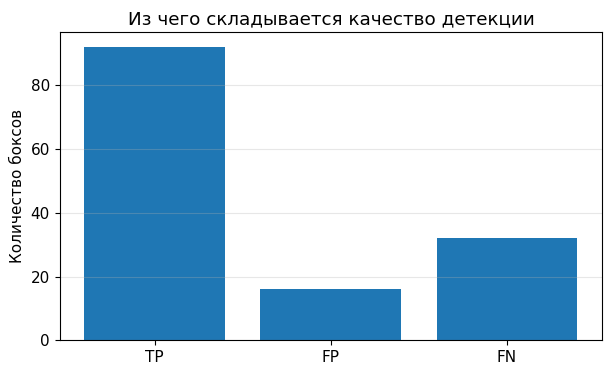

In [15]:

# Собираем диагностику по валидации.
# Если хочется быстрее, можно поставить max_batches=2.

yolo_examples, yolo_summary = collect_yolo_diagnostics(
    model,
    val_loader,
    conf_thr=0.5,
    raw_conf_thr=0.05,
    nms_iou_thr=0.4,
    match_iou_thr=0.5,
    max_batches=None,
)

print_yolo_diagnostic_summary(yolo_summary)

# Небольшой наглядный barplot по главным ошибкам.
plt.figure(figsize=(7, 4))
plt.bar(["TP", "FP", "FN"], [yolo_summary["TP"], yolo_summary["FP"], yolo_summary["FN"]])
plt.title("Из чего складывается качество детекции")
plt.ylabel("Количество боксов")
plt.grid(axis="y", alpha=0.3)
plt.show()


### Визуализация предсказаний: худшие и лучшие примеры

Самая полезная часть для отчёта: видно не только итоговую метрику, но и **почему она такая**.

В каждой строке:

1. `GT` — настоящие боксы;
2. `Objectness map` — уверенность по ячейкам сетки;
3. `Raw candidates` — кандидаты до NMS с низким threshold;
4. `Final + errors` — итог после NMS, где:
   - `TP` — корректное предсказание;
   - `FP` — лишний bbox;
   - `FN` — пропущенный объект.

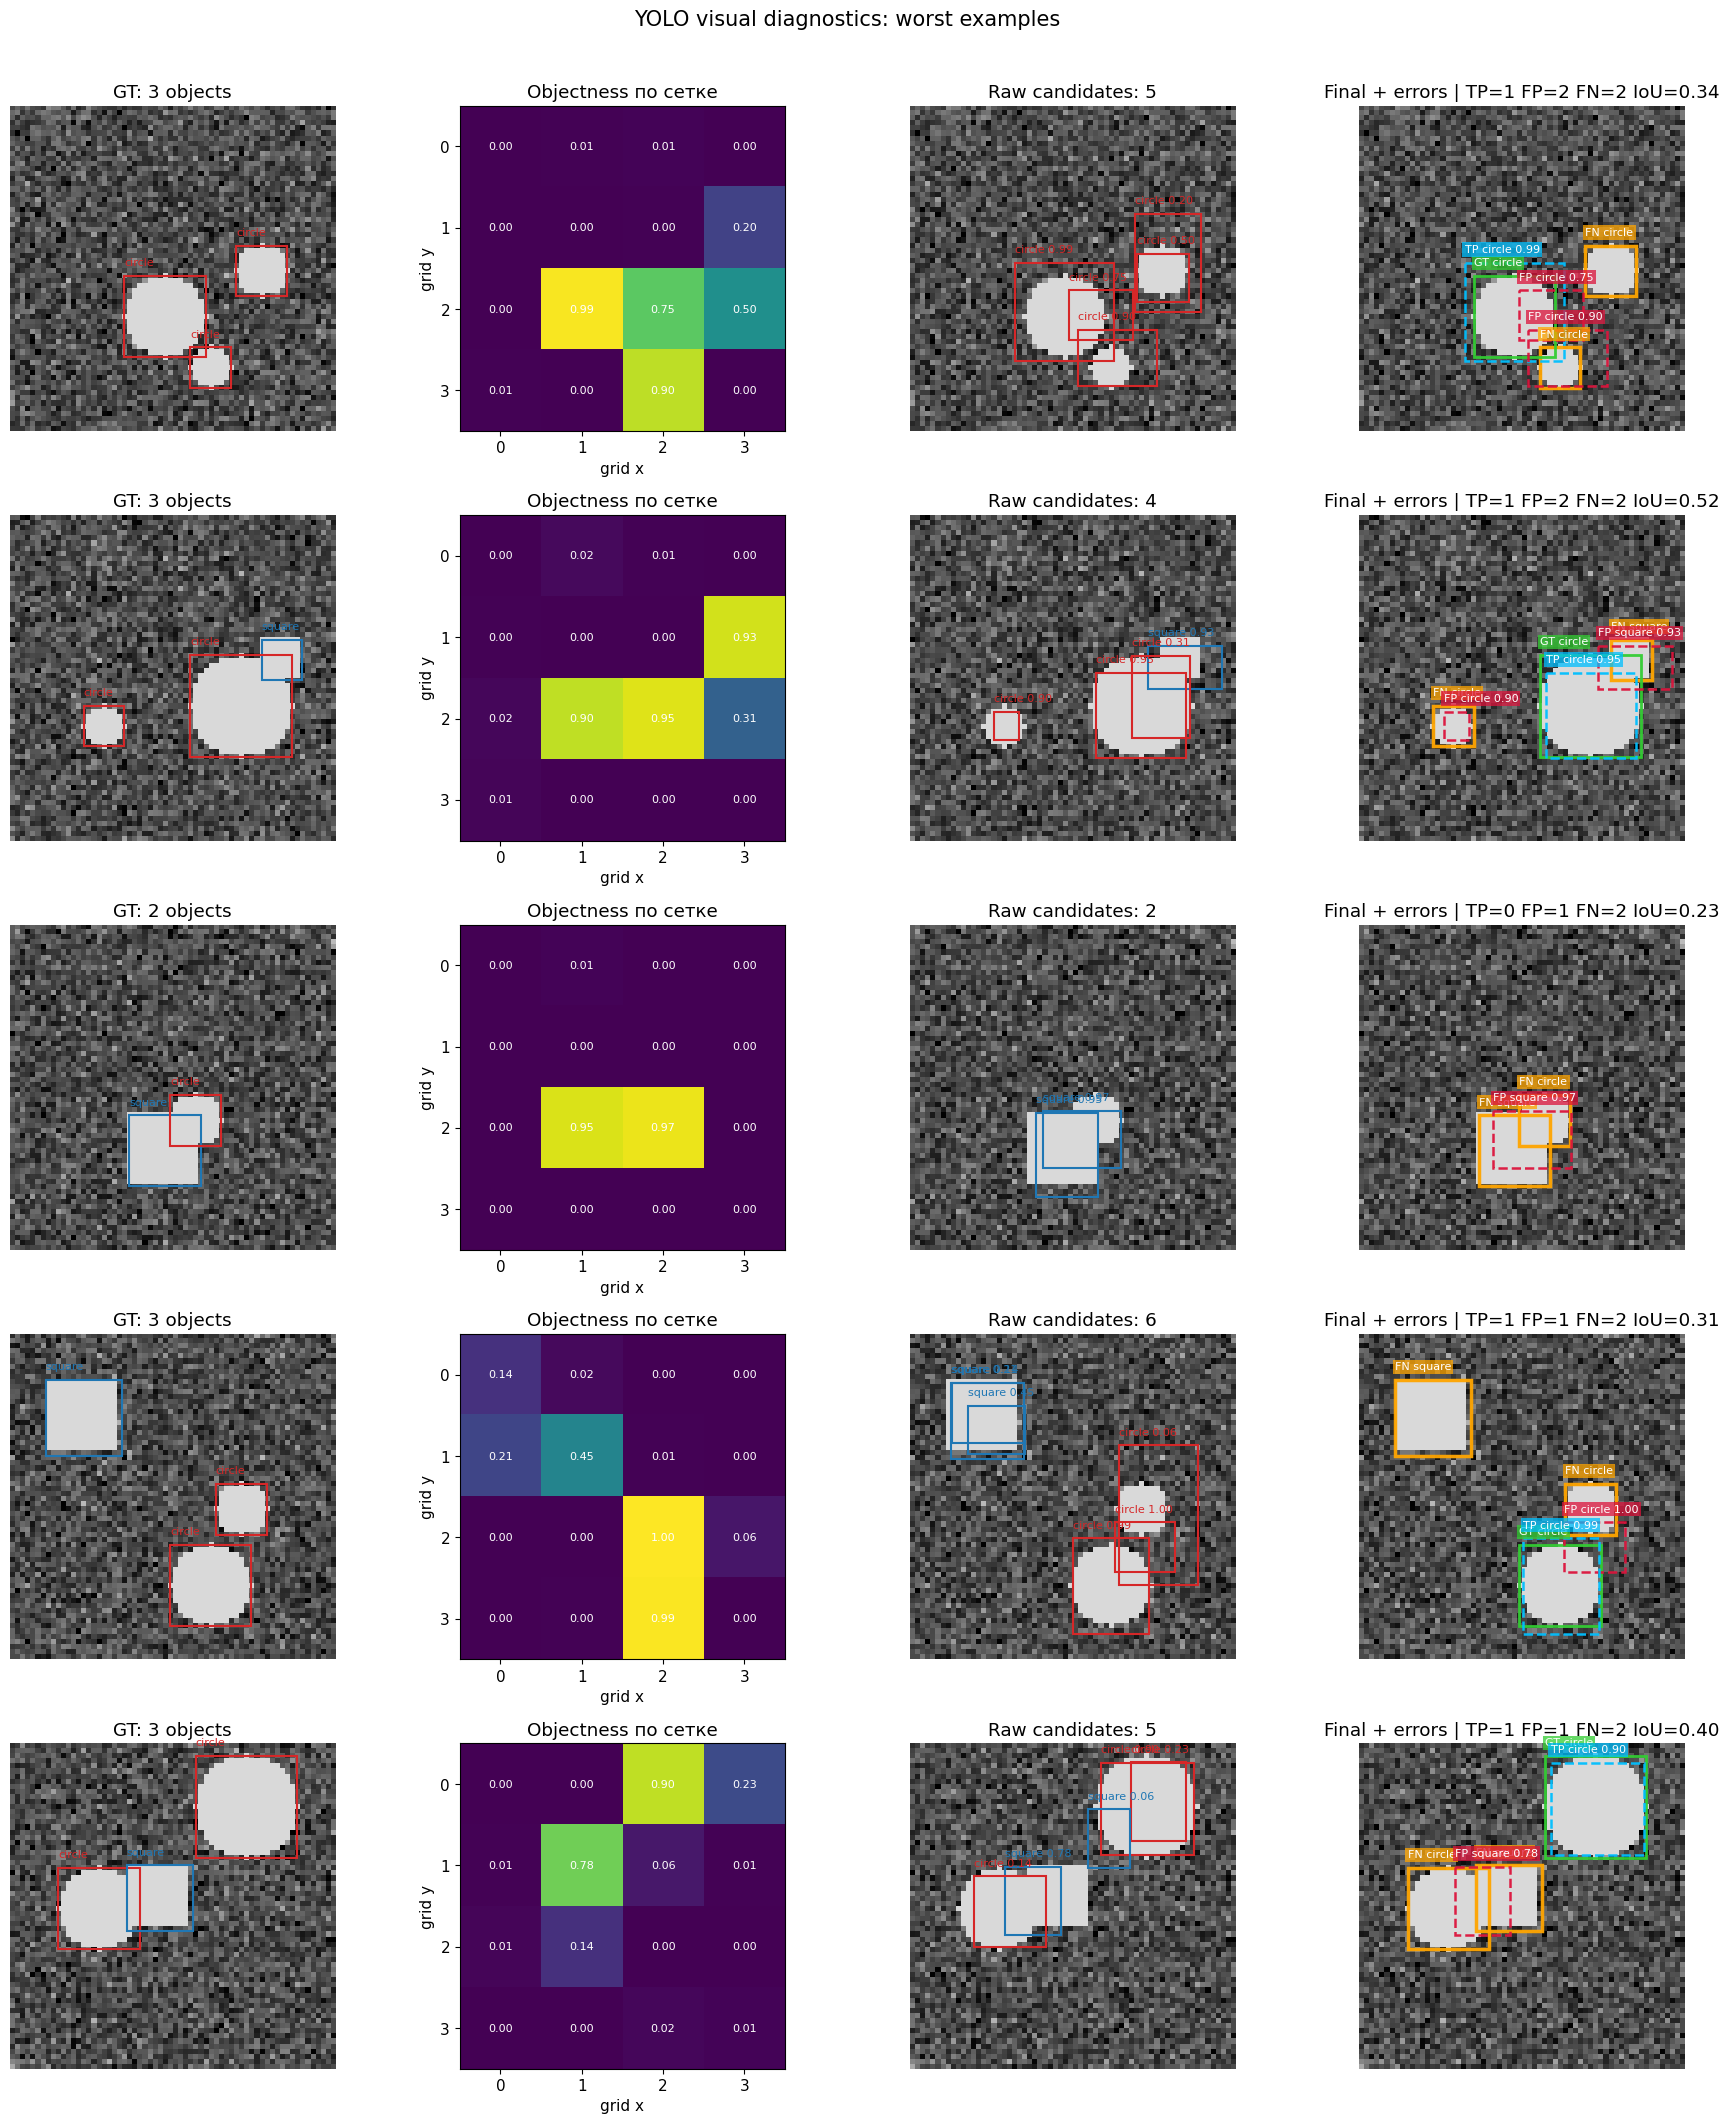

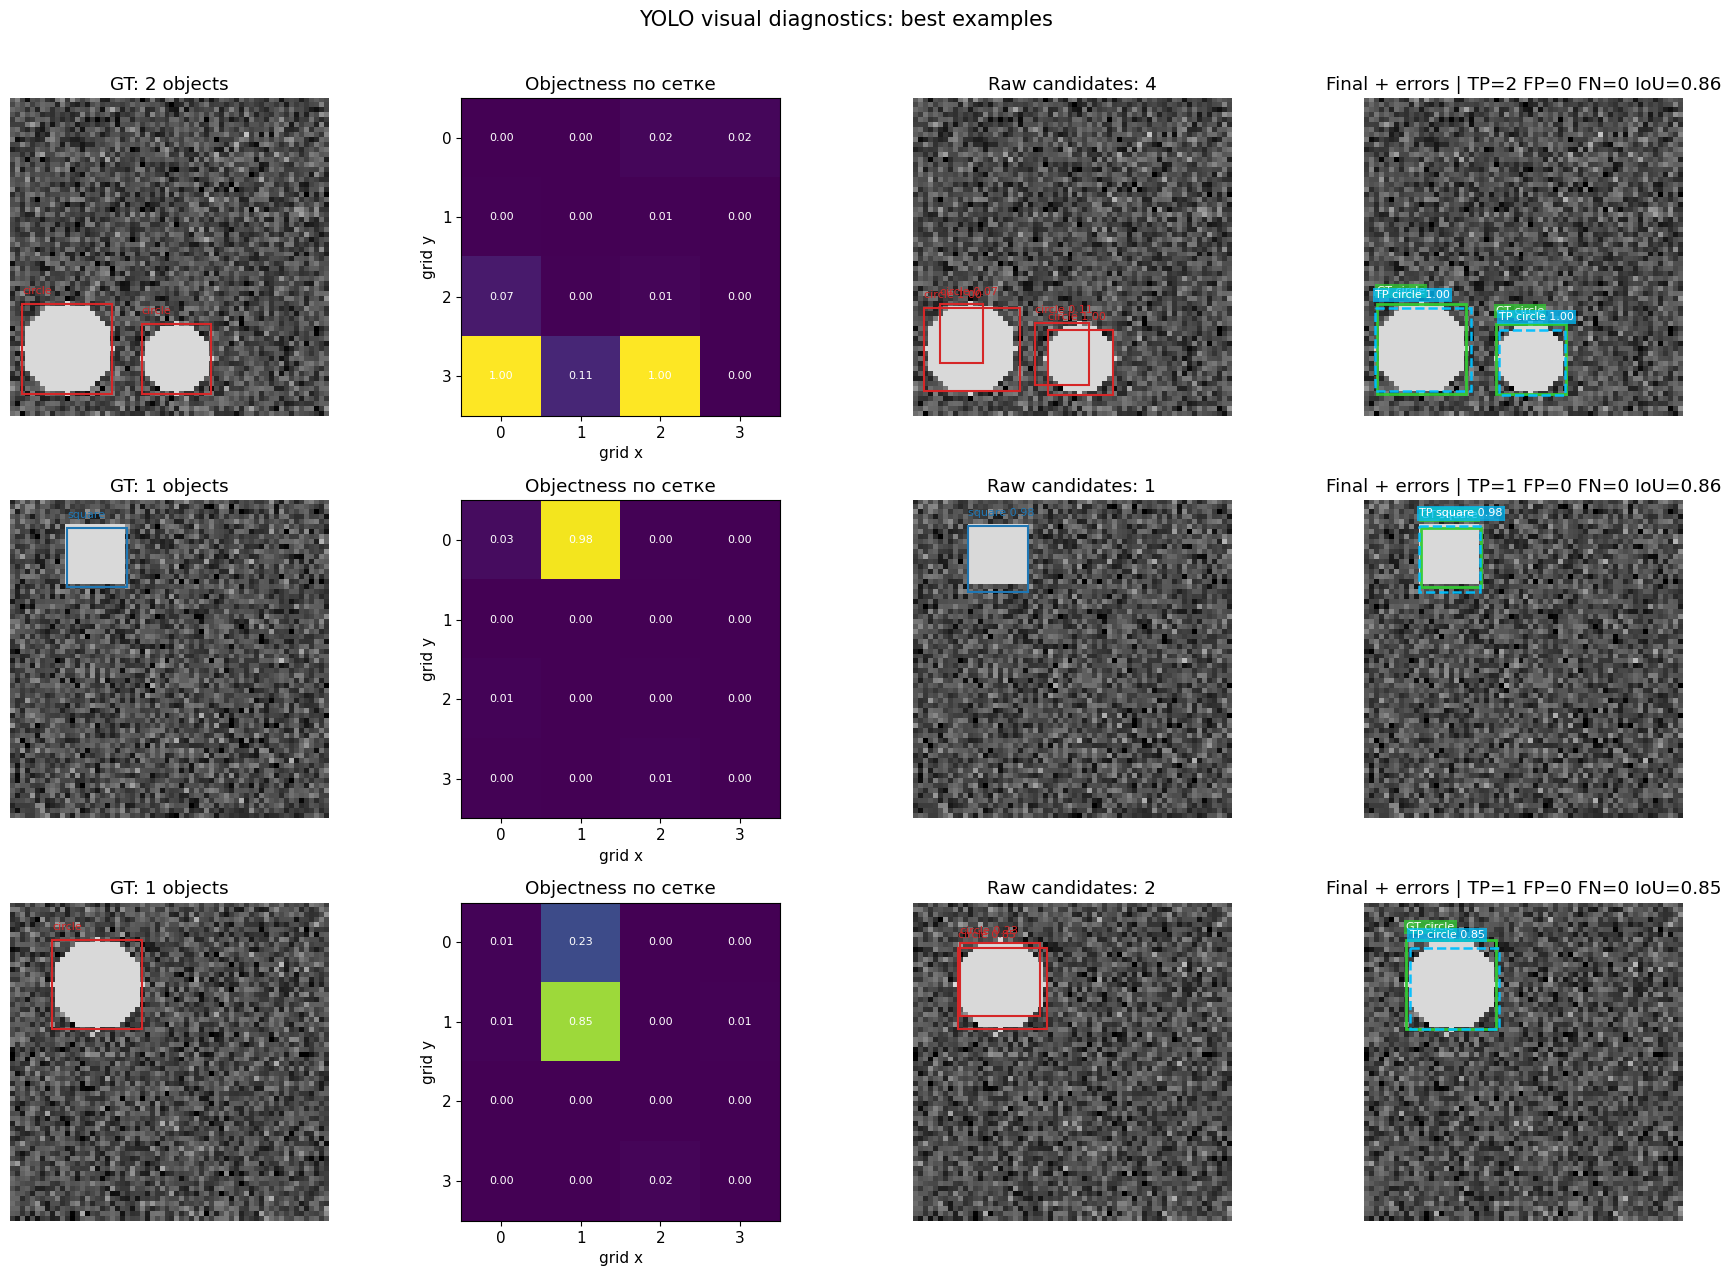

In [16]:

def _select_examples(examples, mode="worst", n=5):
    if mode == "worst":
        return sorted(examples, key=lambda e: e["error_score"], reverse=True)[:n]
    if mode == "best":
        return sorted(examples, key=lambda e: e["error_score"])[:n]
    if mode == "random":
        rng = np.random.default_rng(42)
        idx = rng.choice(len(examples), size=min(n, len(examples)), replace=False)
        return [examples[i] for i in idx]
    raise ValueError("mode должен быть 'worst', 'best' или 'random'")


def show_yolo_examples(examples, mode="worst", n=5, match_iou_thr=0.5):
    selected = _select_examples(examples, mode=mode, n=n)
    rows = len(selected)
    fig, axes = plt.subplots(rows, 4, figsize=(18, 4.2 * rows))
    if rows == 1:
        axes = axes[None, :]

    for row, ex in enumerate(selected):
        img = ex["image"]
        gt = ex["gt"]
        raw_pred = ex["raw_pred"]
        pred = ex["pred"]
        stats = ex["stats"]

        # 1. GT
        draw_boxes(
            axes[row, 0],
            img,
            _to_numpy_boxes(gt),
            title=f"GT: {len(gt)} objects",
        )

        # 2. Objectness heatmap
        draw_objectness_map(
            axes[row, 1],
            ex["objectness"],
            title="Objectness по сетке",
        )

        # 3. Raw candidates before NMS
        draw_boxes(
            axes[row, 2],
            img,
            _to_numpy_boxes(raw_pred),
            title=f"Raw candidates: {len(raw_pred)}",
        )

        # 4. Final predictions with error status
        title = (
            f"Final + errors | "
            f"TP={stats['tp']} FP={stats['fp']} FN={stats['fn']} "
            f"IoU={stats['mean_best_iou']:.2f}"
        )
        draw_error_overlay(
            axes[row, 3],
            img,
            gt,
            pred,
            iou_thr=match_iou_thr,
            title=title,
        )

    plt.suptitle(
        f"YOLO visual diagnostics: {mode} examples",
        fontsize=15,
        y=1.01,
    )
    plt.tight_layout()
    plt.show()


# Самые интересные для отчёта — худшие ошибки.
show_yolo_examples(yolo_examples, mode="worst", n=5, match_iou_thr=0.5)

# Для контраста можно показать лучшие примеры.
show_yolo_examples(yolo_examples, mode="best", n=3, match_iou_thr=0.5)


### Как confidence threshold влияет на предсказания

Этот график полезен, если модель либо выдаёт слишком много лишних боксов, либо наоборот почти ничего не находит. Обычно при росте `conf_thr`:

- `precision` растёт, потому что остаются только более уверенные предсказания;
- `recall` падает, потому что часть объектов пропускается;
- среднее число боксов на изображение уменьшается.

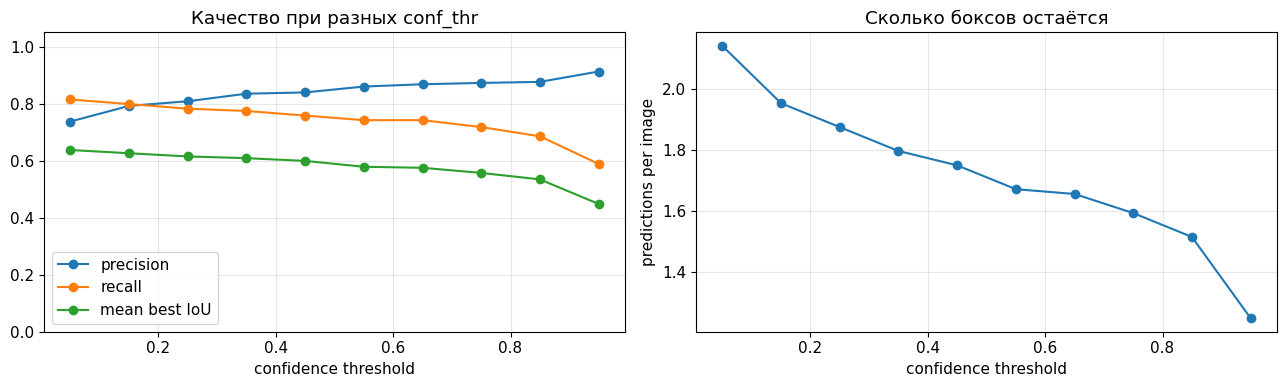

Лучший threshold часто выбирают как компромисс между precision и recall.


In [17]:

def threshold_sweep_from_examples(
    examples,
    thresholds=None,
    decode_fn=decode_predictions,
    nms_iou_thr=0.4,
    match_iou_thr=0.5,
):
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 10)

    rows = []
    for thr in thresholds:
        tp = fp = fn = 0
        n_pred = 0
        best_ious = []

        for ex in examples:
            pred = decode_fn(ex["raw_output"], conf_thr=float(thr)).detach().cpu()
            pred = nms(pred, iou_thr=nms_iou_thr).detach().cpu()
            stats = detailed_match_boxes(pred, ex["gt"], iou_thr=match_iou_thr)
            tp += stats["tp"]
            fp += stats["fp"]
            fn += stats["fn"]
            n_pred += len(pred)
            best_ious.extend(stats["gt_best_iou"])

        rows.append({
            "threshold": float(thr),
            "precision": tp / max(1, tp + fp),
            "recall": tp / max(1, tp + fn),
            "avg_predictions": n_pred / max(1, len(examples)),
            "mean_best_iou": float(np.mean(best_ious)) if best_ious else 0.0,
        })

    return rows


def plot_threshold_sweep(rows):
    thresholds = [r["threshold"] for r in rows]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(thresholds, [r["precision"] for r in rows], marker="o", label="precision")
    axes[0].plot(thresholds, [r["recall"] for r in rows], marker="o", label="recall")
    axes[0].plot(thresholds, [r["mean_best_iou"] for r in rows], marker="o", label="mean best IoU")
    axes[0].set_xlabel("confidence threshold")
    axes[0].set_ylim(0, 1.05)
    axes[0].set_title("Качество при разных conf_thr")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(thresholds, [r["avg_predictions"] for r in rows], marker="o")
    axes[1].set_xlabel("confidence threshold")
    axes[1].set_ylabel("predictions per image")
    axes[1].set_title("Сколько боксов остаётся")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


threshold_rows = threshold_sweep_from_examples(yolo_examples)
plot_threshold_sweep(threshold_rows)

print("Лучший threshold часто выбирают как компромисс между precision и recall.")


### Короткий вывод для отчёта

По визуализации видно не только количество ошибок, но и их типы. Если модель даёт много `FP`, значит она слишком легко ставит высокий objectness или threshold слишком низкий. Если много `FN`, модель пропускает объекты: помогает увеличить число эпох, снизить `conf_thr`, улучшить loss для objectness или использовать anchors / `B > 1`. `Objectness map` показывает, какие ячейки сетки модель считает ответственными за объекты, а сравнение `Raw candidates` и `Final + errors` показывает эффект NMS.

## Вывод по основному эксперименту

После обучения `train_loss` должен убывать: модель учится одновременно находить занятые ячейки, уточнять координаты bbox и выбирать класс объекта. `precision` показывает, какая доля предсказанных боксов действительно совпала с объектами, а `recall` — какая доля реальных объектов была найдена.

Главное ограничение базовой версии — **один bbox на ячейку**. Если центры двух объектов попали в одну ячейку, второй объект теряется уже на этапе `encode_target`, поэтому в сложных сценах recall ограничен архитектурно. Это как раз мотивирует дополнительные задания: `B>1`, anchors и mAP.

# 10. Что нужно сдать

1. Реализованные функции и классы:
   - `encode_target`
   - `SimpleYOLO`
   - `yolo_loss`
   - `decode_predictions`
   - `nms`
2. Графики:
   - `train_loss` по эпохам,
   - `val_precision` и `val_recall` по эпохам.
3. Визуализация: 4 пары `(GT, prediction)` для разных валидационных примеров.
4. Краткий отчёт с ответами на вопросы из §12.
5. Дополнительные задания:
   - `B > 1` bbox на ячейку,
   - anchor boxes,
   - `mAP@0.5`,
   - `sqrt`-параметризация ширины/высоты.


# 11. Дополнительные задания (повышенной сложности)

1. **B > 1 боксов на ячейку.** Расширьте выход модели до $B \cdot (5 + C/?)$ каналов и реализуйте «ответственный» предиктор — тот из $B$, у которого IoU с GT выше.
2. **Anchor boxes.** Введите якоря разных размеров; пусть каждая ячейка предсказывает поправки к ним.
3. **mAP вместо P/R.** Реализуйте mean Average Precision (`mAP@0.5`) по всему валидационному набору, как в стандартных бенчмарках.
4. **`sqrt`-параметризация.** Замените `(t_w - tw)^2` на `(\sqrt{t_w} - \sqrt{tw})^2`, как в исходном YOLO-v1, и сравните качество детекции маленьких объектов.

# 11.1. Дополнительное задание: несколько боксов на ячейку (`B > 1`)

В базовой версии каждая ячейка предсказывает ровно один bbox. Это ограничивает модель: если в одной ячейке оказались центры нескольких объектов, часть разметки теряется. Ниже реализована версия с несколькими предсказателями на ячейку.

Используем формат выхода:

$$(B_{box} \cdot 5 + C, S, S),$$

где для каждого предсказателя хранятся `conf, tx, ty, tw, th`, а классы остаются общими для ячейки. Ответственным предсказателем становится тот, чей bbox имеет максимальный IoU с ground truth.


In [18]:
def xywh_iou_tensor(a, b, eps=1e-7):
    """Векторизованный IoU для bbox в формате (..., 4): cx, cy, w, h."""
    a = a.float()
    b = b.float()

    a_x1 = a[..., 0] - a[..., 2] / 2
    a_y1 = a[..., 1] - a[..., 3] / 2
    a_x2 = a[..., 0] + a[..., 2] / 2
    a_y2 = a[..., 1] + a[..., 3] / 2

    b_x1 = b[..., 0] - b[..., 2] / 2
    b_y1 = b[..., 1] - b[..., 3] / 2
    b_x2 = b[..., 0] + b[..., 2] / 2
    b_y2 = b[..., 1] + b[..., 3] / 2

    inter_x1 = torch.maximum(a_x1, b_x1)
    inter_y1 = torch.maximum(a_y1, b_y1)
    inter_x2 = torch.minimum(a_x2, b_x2)
    inter_y2 = torch.minimum(a_y2, b_y2)

    inter = (inter_x2 - inter_x1).clamp(min=0) * (inter_y2 - inter_y1).clamp(min=0)
    area_a = (a_x2 - a_x1).clamp(min=0) * (a_y2 - a_y1).clamp(min=0)
    area_b = (b_x2 - b_x1).clamp(min=0) * (b_y2 - b_y1).clamp(min=0)
    union = area_a + area_b - inter
    return inter / (union + eps)


class MultiBoxYOLO(nn.Module):
    """YOLO-вариант с несколькими bbox-предсказателями на каждую ячейку."""
    def __init__(self, S=GRID, C=NUM_CLASSES, boxes_per_cell=2):
        super().__init__()
        self.S = S
        self.C = C
        self.boxes_per_cell = boxes_per_cell
        self.backbone = nn.Sequential(
            conv_bn_relu(1, 16),   nn.MaxPool2d(2),
            conv_bn_relu(16, 32),  nn.MaxPool2d(2),
            conv_bn_relu(32, 64),  nn.MaxPool2d(2),
            conv_bn_relu(64, 128), nn.MaxPool2d(2),
        )
        self.head = nn.Conv2d(128, boxes_per_cell * 5 + C, kernel_size=1)

    def forward(self, x):
        return self.head(self.backbone(x))


def multibox_yolo_loss(pred, target, boxes_per_cell=2, lambda_coord=5.0, lambda_noobj=0.5):
    """
    Loss для B>1 bbox на ячейку.
    pred:   (N, B*5 + C, S, S)
    target: (N, 5 + C, S, S), как в базовом варианте.
    """
    N, _, S, _ = pred.shape
    Bp = boxes_per_cell
    C = target.shape[1] - 5
    device = pred.device

    box_pred = pred[:, :Bp * 5].reshape(N, Bp, 5, S, S)
    class_logits = pred[:, Bp * 5:]

    conf_pred = torch.sigmoid(box_pred[:, :, 0:1])      # (N, B, 1, S, S)
    coord_pred = torch.sigmoid(box_pred[:, :, 1:5])     # (N, B, 4, S, S)
    obj_mask = (target[:, 0:1] == 1)                    # (N, 1, S, S)

    responsible = torch.zeros_like(conf_pred, dtype=torch.bool)

    # Назначаем ответственного предсказателя по максимальному IoU с GT.
    with torch.no_grad():
        for n in range(N):
            for i in range(S):
                for j in range(S):
                    if not obj_mask[n, 0, i, j]:
                        continue
                    tx, ty, tw, th = target[n, 1:5, i, j]
                    gt_box = torch.tensor([(j + tx) / S, (i + ty) / S, tw, th],
                                          device=device, dtype=pred.dtype)

                    pred_boxes = []
                    for k in range(Bp):
                        ptx, pty, pw, ph = coord_pred[n, k, :, i, j]
                        pred_boxes.append(torch.stack([(j + ptx) / S, (i + pty) / S, pw, ph]))
                    pred_boxes = torch.stack(pred_boxes)
                    best_k = int(torch.argmax(xywh_iou_tensor(pred_boxes, gt_box.unsqueeze(0))).item())
                    responsible[n, best_k, 0, i, j] = True

    coord_target = target[:, 1:5].unsqueeze(1).expand(-1, Bp, -1, -1, -1)
    resp_float = responsible.float()

    loss_coord = ((coord_pred - coord_target) ** 2 * resp_float).sum()
    loss_obj = ((conf_pred - 1.0) ** 2 * resp_float).sum()
    loss_noobj = (conf_pred ** 2 * (~responsible).float()).sum()

    class_idx = target[:, 5:].argmax(dim=1)
    logits_flat = class_logits.permute(0, 2, 3, 1).reshape(-1, C)
    idx_flat = class_idx.reshape(-1)
    mask_flat = obj_mask[:, 0].reshape(-1).bool()
    loss_class = (F.cross_entropy(logits_flat[mask_flat], idx_flat[mask_flat], reduction="sum")
                  if mask_flat.any() else torch.tensor(0.0, device=device))

    return (lambda_coord * loss_coord + loss_obj + lambda_noobj * loss_noobj + loss_class) / N


def decode_multibox_predictions(pred, conf_thr=0.5, S=GRID, C=NUM_CLASSES, boxes_per_cell=2):
    """Декодирование выхода MultiBoxYOLO для одного изображения."""
    boxes = []
    Bp = boxes_per_cell
    box_pred = pred[:Bp * 5].reshape(Bp, 5, S, S)
    class_logits = pred[Bp * 5:]

    for i in range(S):
        for j in range(S):
            cls_prob, cls = torch.softmax(class_logits[:, i, j], dim=0).max(dim=0)
            for k in range(Bp):
                conf = torch.sigmoid(box_pred[k, 0, i, j])
                if conf <= conf_thr:
                    continue
                tx, ty, w, h = torch.sigmoid(box_pred[k, 1:5, i, j])
                cx = (j + tx) / S
                cy = (i + ty) / S
                score = conf * cls_prob
                boxes.append(torch.stack([
                    cx.clamp(0, 1), cy.clamp(0, 1),
                    w.clamp(1e-6, 1), h.clamp(1e-6, 1),
                    cls.float(), score.clamp(0, 1)
                ]))

    return torch.stack(boxes) if boxes else torch.zeros(0, 6, device=pred.device)


# 11.2. Дополнительное задание: anchor boxes

Anchor boxes помогают модели стартовать не с произвольной ширины и высоты, а с нескольких типичных размеров объектов. Для этого предсказываем не саму ширину/высоту, а поправки к якорю:

$$w = a_w \cdot e^{t_w}, \qquad h = a_h \cdot e^{t_h}.$$

Для синтетического датасета разумные якоря — примерно `0.16×0.16` и `0.28×0.28`: они соответствуют объектам около 10 и 18 пикселей на изображении 64×64.


In [19]:
DEFAULT_ANCHORS = torch.tensor([
    [0.16, 0.16],
    [0.28, 0.28],
], dtype=torch.float32)


def wh_iou(wh, anchors, eps=1e-7):
    """IoU только по ширине/высоте, центры считаем совпадающими."""
    wh = wh.unsqueeze(0) if wh.ndim == 1 else wh
    inter = torch.minimum(wh[:, None, 0], anchors[None, :, 0]) * torch.minimum(wh[:, None, 1], anchors[None, :, 1])
    area_wh = wh[:, 0:1] * wh[:, 1:2]
    area_a = anchors[:, 0] * anchors[:, 1]
    return inter / (area_wh + area_a[None, :] - inter + eps)


class AnchorYOLO(nn.Module):
    """YOLO с anchor boxes: на каждый anchor предсказываем conf, tx, ty, tw, th."""
    def __init__(self, anchors=DEFAULT_ANCHORS, S=GRID, C=NUM_CLASSES):
        super().__init__()
        self.S = S
        self.C = C
        self.register_buffer("anchors", anchors.float())
        A = len(anchors)
        self.backbone = nn.Sequential(
            conv_bn_relu(1, 16),   nn.MaxPool2d(2),
            conv_bn_relu(16, 32),  nn.MaxPool2d(2),
            conv_bn_relu(32, 64),  nn.MaxPool2d(2),
            conv_bn_relu(64, 128), nn.MaxPool2d(2),
        )
        self.head = nn.Conv2d(128, A * 5 + C, kernel_size=1)

    def forward(self, x):
        return self.head(self.backbone(x))


def anchor_yolo_loss(pred, target, anchors=DEFAULT_ANCHORS, lambda_coord=5.0, lambda_noobj=0.5):
    """Loss для anchor-based YOLO."""
    N, _, S, _ = pred.shape
    C = target.shape[1] - 5
    device = pred.device
    anchors = torch.as_tensor(anchors, device=device, dtype=pred.dtype)
    A = anchors.shape[0]

    box_pred = pred[:, :A * 5].reshape(N, A, 5, S, S)
    class_logits = pred[:, A * 5:]

    conf_pred = torch.sigmoid(box_pred[:, :, 0:1])
    xy_pred = torch.sigmoid(box_pred[:, :, 1:3])
    wh_raw_pred = box_pred[:, :, 3:5]
    obj_mask = (target[:, 0:1] == 1)

    responsible = torch.zeros_like(conf_pred, dtype=torch.bool)
    wh_target_log = torch.zeros_like(wh_raw_pred)

    with torch.no_grad():
        for n in range(N):
            for i in range(S):
                for j in range(S):
                    if not obj_mask[n, 0, i, j]:
                        continue
                    gt_wh = target[n, 3:5, i, j].clamp(min=1e-6)
                    best_a = int(torch.argmax(wh_iou(gt_wh, anchors)[0]).item())
                    responsible[n, best_a, 0, i, j] = True
                    wh_target_log[n, best_a, :, i, j] = torch.log(gt_wh / anchors[best_a].clamp(min=1e-6))

    xy_target = target[:, 1:3].unsqueeze(1).expand(-1, A, -1, -1, -1)
    resp_float = responsible.float()

    loss_xy = ((xy_pred - xy_target) ** 2 * resp_float).sum()
    loss_wh = ((wh_raw_pred - wh_target_log) ** 2 * resp_float).sum()
    loss_coord = loss_xy + loss_wh
    loss_obj = ((conf_pred - 1.0) ** 2 * resp_float).sum()
    loss_noobj = (conf_pred ** 2 * (~responsible).float()).sum()

    class_idx = target[:, 5:].argmax(dim=1)
    logits_flat = class_logits.permute(0, 2, 3, 1).reshape(-1, C)
    idx_flat = class_idx.reshape(-1)
    mask_flat = obj_mask[:, 0].reshape(-1).bool()
    loss_class = (F.cross_entropy(logits_flat[mask_flat], idx_flat[mask_flat], reduction="sum")
                  if mask_flat.any() else torch.tensor(0.0, device=device))

    return (lambda_coord * loss_coord + loss_obj + lambda_noobj * loss_noobj + loss_class) / N


def decode_anchor_predictions(pred, anchors=DEFAULT_ANCHORS, conf_thr=0.5, S=GRID, C=NUM_CLASSES):
    """Декодирование anchor-based выхода для одного изображения."""
    anchors = torch.as_tensor(anchors, device=pred.device, dtype=pred.dtype)
    A = anchors.shape[0]
    boxes = []
    box_pred = pred[:A * 5].reshape(A, 5, S, S)
    class_logits = pred[A * 5:]

    for i in range(S):
        for j in range(S):
            cls_prob, cls = torch.softmax(class_logits[:, i, j], dim=0).max(dim=0)
            for a in range(A):
                conf = torch.sigmoid(box_pred[a, 0, i, j])
                if conf <= conf_thr:
                    continue
                tx, ty = torch.sigmoid(box_pred[a, 1:3, i, j])
                tw, th = box_pred[a, 3:5, i, j]
                cx = (j + tx) / S
                cy = (i + ty) / S
                wh = anchors[a] * torch.exp(torch.stack([tw, th]))
                score = conf * cls_prob
                boxes.append(torch.stack([
                    cx.clamp(0, 1), cy.clamp(0, 1),
                    wh[0].clamp(1e-6, 1), wh[1].clamp(1e-6, 1),
                    cls.float(), score.clamp(0, 1)
                ]))

    return torch.stack(boxes) if boxes else torch.zeros(0, 6, device=pred.device)


# 11.3. Дополнительное задание: `mAP@0.5`

Precision/recall при одном пороге уверенности полезны для быстрой диагностики, но стандартная метрика детекции — Average Precision. Ниже реализована `mAP@0.5`: предсказания сортируются по score, затем для каждого класса строится precision-recall кривая при IoU-пороге 0.5.


In [22]:
def compute_average_precision(recalls, precisions):
    """Площадь под precision-recall кривой с precision-envelope."""
    if len(recalls) == 0:
        return 0.0
    recalls = np.asarray(recalls, dtype=np.float64)
    precisions = np.asarray(precisions, dtype=np.float64)

    mrec = np.concatenate([[0.0], recalls, [1.0]])
    mpre = np.concatenate([[0.0], precisions, [0.0]])

    for i in range(len(mpre) - 2, -1, -1):
        mpre[i] = max(mpre[i], mpre[i + 1])

    changing = np.where(mrec[1:] != mrec[:-1])[0]
    ap = np.sum((mrec[changing + 1] - mrec[changing]) * mpre[changing + 1])
    return float(ap)


def map50_from_detections(all_preds, all_gts, num_classes=NUM_CLASSES, iou_thr=0.5):
    """
    all_preds: список тензоров (N_i, 6) — cx, cy, w, h, cls, score
    all_gts:   список тензоров (M_i, 5) — cx, cy, w, h, cls
    """
    aps = {}

    for cls in range(num_classes):
        gt_by_image = {}
        matched_by_image = {}
        n_gt = 0

        for img_id, gt in enumerate(all_gts):
            cls_gt = [g[:4].cpu() for g in gt if int(g[4].item()) == cls]
            gt_by_image[img_id] = cls_gt
            matched_by_image[img_id] = [False] * len(cls_gt)
            n_gt += len(cls_gt)

        preds = []
        for img_id, det in enumerate(all_preds):
            for p in det:
                if int(p[4].item()) == cls:
                    preds.append((float(p[5].item()), img_id, p[:4].cpu()))
        preds.sort(key=lambda x: x[0], reverse=True)

        if n_gt == 0:
            aps[cls] = np.nan
            continue

        tp = np.zeros(len(preds), dtype=np.float64)
        fp = np.zeros(len(preds), dtype=np.float64)

        for k, (_, img_id, pred_box) in enumerate(preds):
            gt_boxes = gt_by_image[img_id]
            best_iou, best_idx = 0.0, -1
            for gt_idx, gt_box in enumerate(gt_boxes):
                if matched_by_image[img_id][gt_idx]:
                    continue
                iou = bbox_iou_xywh(pred_box, gt_box)
                if iou > best_iou:
                    best_iou, best_idx = iou, gt_idx

            if best_iou >= iou_thr and best_idx >= 0:
                tp[k] = 1.0
                matched_by_image[img_id][best_idx] = True
            else:
                fp[k] = 1.0

        cum_tp = np.cumsum(tp)
        cum_fp = np.cumsum(fp)
        recalls = cum_tp / max(1, n_gt)
        precisions = cum_tp / np.maximum(cum_tp + cum_fp, 1e-9)
        aps[cls] = compute_average_precision(recalls, precisions)

    valid_aps = [ap for ap in aps.values() if not np.isnan(ap)]
    return float(np.mean(valid_aps)) if valid_aps else 0.0, aps


@torch.no_grad()
def evaluate_map50(model, val_loader, decode_fn=decode_predictions, conf_thr=0.05,
                   nms_iou_thr=0.4, map_iou_thr=0.5, device=DEVICE):
    """Считает mAP@0.5 для модели на val_loader."""
    model.eval()
    all_preds, all_gts = [], []

    for imgs, boxes_list in val_loader:
        imgs = imgs.to(device)
        preds = model(imgs)
        for b in range(imgs.size(0)):
            det = decode_fn(preds[b].detach().cpu(), conf_thr=conf_thr)
            det = nms(det, iou_thr=nms_iou_thr)
            all_preds.append(det.cpu())
            all_gts.append(boxes_list[b].cpu())

    return map50_from_detections(all_preds, all_gts, num_classes=NUM_CLASSES, iou_thr=map_iou_thr)


map50, ap_by_class = evaluate_map50(model, val_loader, conf_thr=0.05)
print(f"mAP@0.5 = {map50:.3f}", ap_by_class)


mAP@0.5 = 0.768 {0: 0.7602826794778478, 1: 0.7763760760176864}


# 11.4. Дополнительное задание: `sqrt`-параметризация ширины и высоты

В исходном YOLO-v1 для ширины и высоты использовалась ошибка по корням:

$$(\sqrt{\hat w} - \sqrt{w})^2 + (\sqrt{\hat h} - \sqrt{h})^2.$$

Это уменьшает доминирование больших объектов в coordinate loss и делает обучение чувствительнее к маленьким объектам.


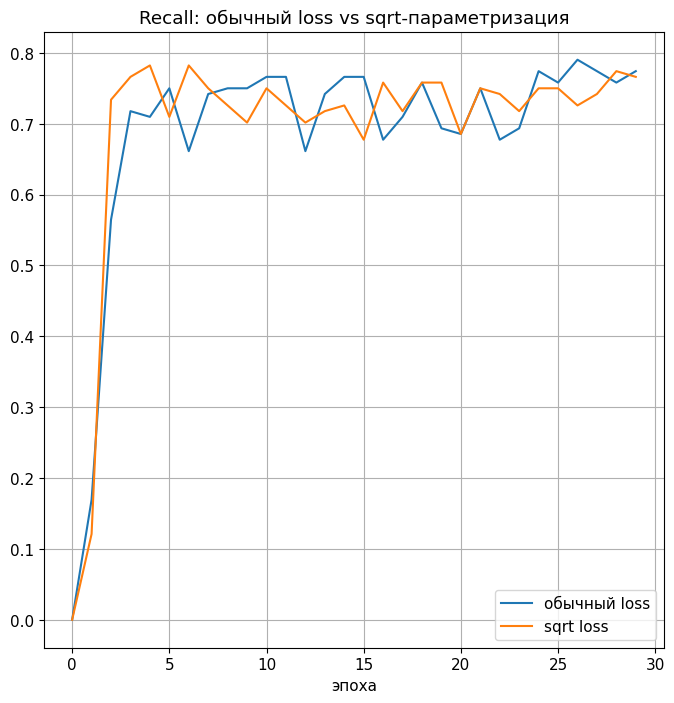

In [23]:
def yolo_loss_sqrt(pred, target, lambda_coord=5.0, lambda_noobj=0.5, eps=1e-6):
    """YOLO-loss со sqrt-параметризацией w/h, как в YOLO-v1."""
    B = pred.shape[0]
    obj_mask = (target[:, 0:1] == 1)
    noobj_mask = (target[:, 0:1] == 0)

    conf_pred = torch.sigmoid(pred[:, 0:1])
    loss_obj = ((conf_pred - 1.0) ** 2 * obj_mask.float()).sum()
    loss_noobj = (conf_pred ** 2 * noobj_mask.float()).sum()

    coord_pred = torch.sigmoid(pred[:, 1:5])
    coord_target = target[:, 1:5]

    # x/y оставляем обычным MSE, w/h считаем в sqrt-шкале.
    xy_loss = ((coord_pred[:, 0:2] - coord_target[:, 0:2]) ** 2 * obj_mask.float()).sum()
    wh_loss = ((torch.sqrt(coord_pred[:, 2:4].clamp(min=eps)) -
                torch.sqrt(coord_target[:, 2:4].clamp(min=eps))) ** 2 * obj_mask.float()).sum()
    loss_coord = xy_loss + wh_loss

    class_logits = pred[:, 5:]
    class_idx = target[:, 5:].argmax(dim=1)
    logits_flat = class_logits.permute(0, 2, 3, 1).reshape(-1, class_logits.shape[1])
    idx_flat = class_idx.reshape(-1)
    mask_flat = obj_mask[:, 0].reshape(-1).bool()
    loss_class = (F.cross_entropy(logits_flat[mask_flat], idx_flat[mask_flat], reduction="sum")
                  if mask_flat.any() else torch.tensor(0.0, device=pred.device))

    return (lambda_coord * loss_coord + loss_obj + lambda_noobj * loss_noobj + loss_class) / B


def train_yolo_custom(model, train_loader, val_loader, loss_fn=yolo_loss,
                      decode_fn=decode_predictions, epochs=30, lr=1e-3,
                      conf_thr=0.5, iou_thr=0.5, device=DEVICE):
    """Универсальный train-loop для сравнения обычного, sqrt, multibox и anchor-loss."""
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_precision": [], "val_recall": []}

    for epoch in range(epochs):
        model.train()
        total = 0.0
        for imgs, boxes_list in train_loader:
            imgs = imgs.to(device)
            target = encode_batch(boxes_list).to(device)
            pred = model(imgs)
            loss = loss_fn(pred, target)
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += loss.item() * imgs.size(0)

        model.eval()
        tp = fp = fn = 0
        with torch.no_grad():
            for imgs, boxes_list in val_loader:
                imgs = imgs.to(device)
                preds = model(imgs)
                for b in range(imgs.size(0)):
                    decoded = decode_fn(preds[b].detach().cpu(), conf_thr=conf_thr)
                    decoded = nms(decoded, iou_thr=0.4)
                    tp_b, fp_b, fn_b = match_boxes(decoded, boxes_list[b], iou_thr=iou_thr)
                    tp += tp_b; fp += fp_b; fn += fn_b

        history["train_loss"].append(total / len(train_loader.dataset))
        history["val_precision"].append(tp / max(1, tp + fp))
        history["val_recall"].append(tp / max(1, tp + fn))
    return history


model_plain = SimpleYOLO().to(DEVICE)
hist_plain = train_yolo_custom(model_plain, train_loader, val_loader, loss_fn=yolo_loss, epochs=30)

model_sqrt = SimpleYOLO().to(DEVICE)
hist_sqrt = train_yolo_custom(model_sqrt, train_loader, val_loader, loss_fn=yolo_loss_sqrt, epochs=30)

plt.plot(hist_plain["val_recall"], label="обычный loss")
plt.plot(hist_sqrt["val_recall"], label="sqrt loss")
plt.title("Recall: обычный loss vs sqrt-параметризация")
plt.xlabel("эпоха")
plt.grid(True); plt.legend(); plt.show()


## Краткие выводы по дополнительным заданиям

1. **`B > 1`** уменьшает проблему «одна ячейка — один объект» и даёт нескольким предсказателям возможность специализироваться на разных формах/размерах объектов.
2. **Anchors** обычно стабилизируют обучение размеров bbox: модели не нужно с нуля угадывать ширину и высоту, она учит поправки к типичным размерам.
3. **`mAP@0.5`** лучше, чем одна пара precision/recall, потому что оценивает качество ранжирования предсказаний по confidence на всём диапазоне порогов.
4. **`sqrt` для `w/h`** полезен для маленьких объектов: одинаковая абсолютная ошибка в ширине/высоте для маленького объекта важнее, чем для большого, и sqrt-шкала частично это учитывает.


# 12. Ответы на вопросы для отчёта

**1. Зачем в YOLO сетка $S \times S$? Что было бы, если выдавать просто список боксов фиксированной длины?**

Сетка превращает задачу детекции в плотное предсказание: каждая пространственная область изображения отвечает за объекты, центры которых попали в эту ячейку. Это удобно для CNN, потому что выход модели сохраняет пространственную структуру изображения. Если выдавать просто фиксированный список боксов, пришлось бы заранее задавать максимальное число объектов, решать проблему порядка боксов в списке и сложнее сопоставлять предсказания с ground truth.

**2. Зачем нужны коэффициенты $\lambda_{coord}=5$ и $\lambda_{noobj}=0.5$? Что произойдёт без них?**

В изображении много пустых ячеек и мало ячеек с объектами. Без понижения веса `noobj` модель может научиться в основном говорить «объекта нет», потому что это быстро уменьшает loss. Коэффициент `lambda_coord=5` усиливает вклад координат, чтобы модель не только находила факт объекта, но и точно подгоняла bbox.

**3. Почему $(t_x, t_y)$ относительно ячейки, а $(t_w, t_h)$ относительно всего изображения?**

Координаты центра относительно ячейки ограничены диапазоном `[0, 1]`, поэтому модели проще учить локальное смещение внутри конкретной клетки. Ширина и высота описывают размер всего объекта, а не положение внутри ячейки, поэтому естественно нормировать их на размер всего изображения.

**4. Зачем нужен NMS? Можно ли обойтись без него?**

NMS нужен, потому что несколько соседних ячеек или несколько bbox-предсказателей могут выдать почти одинаковые рамки для одного объекта. NMS оставляет наиболее уверенную рамку и удаляет дубликаты с большим IoU. Теоретически без NMS можно обойтись, если модель идеально выдаёт ровно один bbox на объект, но на практике это редко выполняется, особенно при низком пороге confidence.

**5. Чем YOLO принципиально отличается от двухстадийных детекторов вроде Faster R-CNN?**

YOLO — одностадийный детектор: он сразу предсказывает bbox, objectness и классы на плотной сетке. Faster R-CNN сначала генерирует region proposals, а затем классифицирует и уточняет их. Поэтому YOLO обычно быстрее и проще для real-time задач, а двухстадийные модели часто выигрывают в точности, особенно на сложных сценах с маленькими объектами и сильным перекрытием.
